# Parameter covariance and identifiability

Fit a kinetic model to noisy data, then ask the solver how certain the
fitted parameters are. Everything comes from ONE ordinary solve: declare
which variables are the estimated parameters and which container holds
the residuals, solve, and call `covariance(m)` with no further
information. The covariance is read off the held KKT factorization (one
backsolve per parameter, no extra optimization).

A Monte Carlo check (refitting hundreds of synthetic datasets) confirms
the reported confidence ellipse is the real sampling distribution, and a
short-horizon variant shows what unidentifiability looks like in these
numbers.

Relation to `pyomo.contrib.parmest`: parmest is a full estimation
workflow (multi-experiment data management, bootstrap, likelihood-ratio
regions) at the price of restructuring your problem into its experiment
framework. `covariance()` is a post-solve primitive: your model as
written, asymptotic covariance and identifiability diagnostics from the
factorization the solve already produced. Use parmest for
multi-experiment campaigns and non-asymptotic intervals; use this to
interrogate the fit you already have.

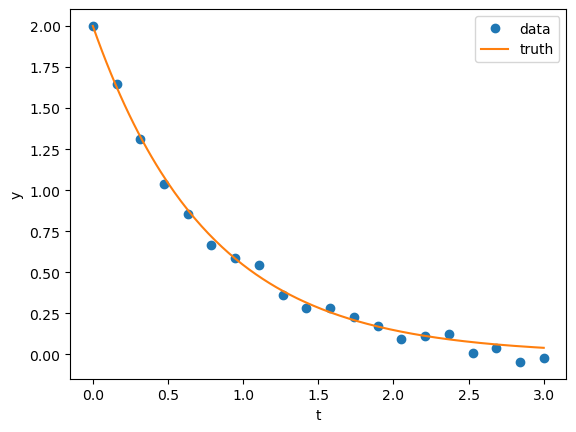

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pyomo.environ as pyo

import pyomo_pounce  # registers 'pounce' with SolverFactory
from pyomo_pounce import covariance, declare_estimated, declare_residual

# Synthetic experiment: first-order decay y = A * exp(-k t) + noise
A_TRUE, K_TRUE, SIGMA = 2.0, 1.3, 0.05
rng = np.random.default_rng(7)
t_data = np.linspace(0.0, 3.0, 20)
y_data = A_TRUE * np.exp(-K_TRUE * t_data) + SIGMA * rng.standard_normal(20)

plt.plot(t_data, y_data, "o", label="data")
tt = np.linspace(0, 3, 200)
plt.plot(tt, A_TRUE * np.exp(-K_TRUE * tt), label="truth")
plt.xlabel("t"); plt.ylabel("y"); plt.legend(); plt.show()

## 1. Declare, solve once, ask

The estimation NLP with explicit residual variables. `declare_estimated`
flags the fitted parameters (they stay free); `declare_residual` flags
the residual container, from which the noise variance is estimated
(count and SSR both derived, nothing passed by hand).

In [2]:
def build(t, y, declare=True):
    m = pyo.ConcreteModel()
    m.I = pyo.RangeSet(0, len(t) - 1)
    m.A = pyo.Var(initialize=1.0)
    m.k = pyo.Var(initialize=1.0)
    m.r = pyo.Var(m.I, initialize=0.0)
    m.res = pyo.Constraint(
        m.I, rule=lambda mm, i: mm.r[i]
        == float(y[i]) - mm.A * pyo.exp(-mm.k * float(t[i])))
    m.obj = pyo.Objective(expr=sum(m.r[i] ** 2 for i in m.I))
    if declare:
        declare_estimated(m.A, m.k)
        declare_residual(m.r)
    return m

m = build(t_data, y_data)
pyo.SolverFactory("pounce").solve(m)          # one ordinary solve
A_hat, k_hat = pyo.value(m.A), pyo.value(m.k)

cov = covariance(m)                           # zero arguments
print(f"A = {A_hat:.4f} +/- {cov.std_err[m.A]:.4f}   (true {A_TRUE})")
print(f"k = {k_hat:.4f} +/- {cov.std_err[m.k]:.4f}   (true {K_TRUE})")
print(f"sigma_hat = {np.sqrt(cov.sigma_sq):.4f}        (true {SIGMA})")
print(f"correlation(A, k) = {cov.correlation[m.A, m.k]:+.3f}")

A = 2.0039 +/- 0.0316   (true 2.0)
k = 1.3309 +/- 0.0329   (true 1.3)
sigma_hat = 0.0420        (true 0.05)
correlation(A, k) = +0.629


## 2. The confidence ellipse, validated by Monte Carlo

The 95% ellipse describes the sampling distribution of the estimates
around the truth. Overlaying it (centered at the true parameters) on
1000 independent refits: about 95% should land inside. Two statistical
details make this an honest test: the ellipse is centered at the truth
(two independent estimates differ with covariance 2 Sigma, so centering
on one estimate would cover only ~78%), and it uses the KNOWN noise
variance (an ellipse built from one dataset's sigma_hat inherits that
dataset's chi-square fluctuation).

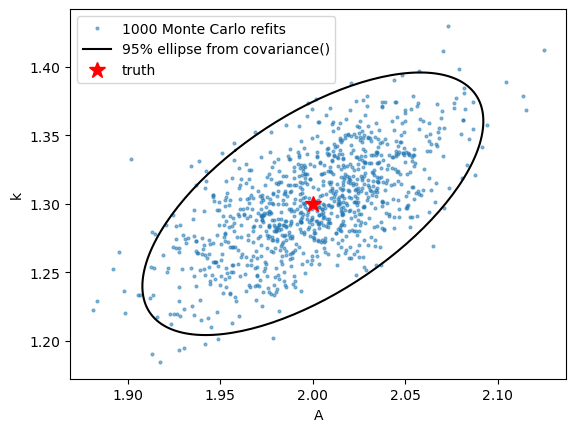

refits inside the 95% ellipse: 95.8%
empirical covariance of the refits:
[[0.001474 0.000921]
 [0.000921 0.001385]]
covariance() prediction:
[[0.001419 0.000929]
 [0.000929 0.001537]]


In [3]:
def refit(seed):
    r = np.random.default_rng(seed)
    y = A_TRUE * np.exp(-K_TRUE * t_data) + SIGMA * r.standard_normal(20)
    mm = build(t_data, y, declare=False)      # plain solves for the refits
    pyo.SolverFactory("pounce").solve(mm)
    return pyo.value(mm.A), pyo.value(mm.k)

fits = np.array([refit(s) for s in range(1000)])

cov_known = covariance(m, sigma_sq=SIGMA**2)
evals, evecs = np.linalg.eigh(cov_known.matrix)
theta = np.linspace(0, 2 * np.pi, 200)
circle = np.stack([np.cos(theta), np.sin(theta)])
ellipse = (evecs @ (np.sqrt(5.991 * evals)[:, None] * circle)).T  # chi2(2,.95)

plt.plot(fits[:, 0], fits[:, 1], ".", ms=4, alpha=0.5,
         label="1000 Monte Carlo refits")
plt.plot(A_TRUE + ellipse[:, 0], K_TRUE + ellipse[:, 1], "k-",
         label="95% ellipse from covariance()")
plt.plot(A_TRUE, K_TRUE, "r*", ms=12, label="truth")
plt.xlabel("A"); plt.ylabel("k"); plt.legend(); plt.show()

d = fits - np.array([A_TRUE, K_TRUE])
inside = np.einsum("ij,jk,ik->i", d, np.linalg.inv(cov_known.matrix), d) <= 5.991
print(f"refits inside the 95% ellipse: {100 * inside.mean():.1f}%")
print("empirical covariance of the refits:")
print(np.round(np.cov(fits.T), 6))
print("covariance() prediction:")
print(np.round(cov_known.matrix, 6))

## 3. What unidentifiability looks like

Same model, but the data cover only a narrow late window, t in
[2.5, 3.0]. There the fit constrains the local value and slope, and A
is a long extrapolation back to t = 0: A and k are individually almost
unidentifiable, only a combination is pinned. The covariance reports it
before any prediction is made: correlation near +1, standard errors far
beyond the full-window fit, one dominant sloppy eigendirection.

In [4]:
t_late = np.linspace(2.5, 3.0, 20)
y_late = (A_TRUE * np.exp(-K_TRUE * t_late)
          + 0.005 * np.random.default_rng(11).standard_normal(20))

ml = build(t_late, y_late)
ml.A.set_value(2.0); ml.k.set_value(1.3)   # warm start: the late-window
# least-squares surface has garbage local optima far from the truth
pyo.SolverFactory("pounce").solve(ml)
cov_l = covariance(ml)

print(f"A = {pyo.value(ml.A):.3f} +/- {cov_l.std_err[ml.A]:.3f}   "
      f"(full-window: +/- {cov.std_err[m.A]:.4f})")
print(f"k = {pyo.value(ml.k):.3f} +/- {cov_l.std_err[ml.k]:.3f}   "
      f"(full-window: +/- {cov.std_err[m.k]:.4f})")
print(f"correlation(A, k) = {cov_l.correlation[ml.A, ml.k]:+.5f}")
evals_l, evecs_l = cov_l.eigen()
print(f"eigenvalue ratio (sloppy/stiff): {evals_l[-1] / evals_l[0]:.1e}")
print(f"sloppy direction in (A, k): {np.round(evecs_l[:, -1], 3)}")

A = 2.111 +/- 0.608   (full-window: +/- 0.0316)
k = 1.314 +/- 0.107   (full-window: +/- 0.0329)
correlation(A, k) = +0.99857
eigenvalue ratio (sloppy/stiff): 1.2e+04
sloppy direction in (A, k): [-0.985 -0.173]


The full-window fit pins both parameters to a couple percent and its
ellipse matches the Monte Carlo scatter; the late-window fit reports
near-perfect correlation and a dominant sloppy direction, diagnosing
the ill-posed design before any prediction is made. One solve, one
declaration per component, and the diagnosis costs a backsolve per
parameter on the factorization the solve already produced.